# 02 · Salary classifier (Task 2)

> This notebook runs the same steps as `src/train.py`, one cell at a time, with explanations and intermediate results. Both use the shared code in `src/salary/`, so the numbers are identical.

Notebook 01 showed that text alone and timing alone are both not enough. This notebook:
1. builds **text features** that survive dirty text;
2. builds **pattern features** that describe how a payment behaves in the person's history;
3. shows how the features separate salary from other credits;
4. trains the final **logistic regression** on all persons, explains it, and saves the model and
   predictions.

Why logistic regression and not something more complex is shown by the comparison in notebook 03.

The feature code is in `src/salary/features.py`, so that `src/predict.py` computes exactly the
same features for new data.

In [1]:
%matplotlib inline
import json
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from salary.data import load_transactions
from salary.style import COLORS, save, setup

setup()
pd.set_option("display.max_colwidth", 70)
pd.set_option("display.width", 160)
REPORTS = ROOT / "reports"
FIG = REPORTS / "figures"
FIG.mkdir(parents=True, exist_ok=True)


def rounded(df, n=2):
    # Round numeric columns only (dates stay as they are).
    return df.round({c: n for c in df.select_dtypes("number").columns})

In [2]:
from salary.features import (FEATURE_COLS, KEYWORDS, PATTERN_COLS, TEXT_COLS, build_features,
                             normalise_text, text_features, text_key)
from salary.model import THRESHOLD, fit, make_logreg, predict_proba, save_model
from salary.evaluate import oof_predict, person_income, income_metrics

txns = load_transactions()
X = build_features(txns).reset_index(drop=True)   # one row per credit (debits are never salary)
print(f"{len(X):,} candidate credits, {X.is_salary.sum()} salaries, "
      f"{len(TEXT_COLS)} text + {len(PATTERN_COLS)} pattern = {len(FEATURE_COLS)} features")

2,093 candidate credits, 876 salaries, 16 text + 21 pattern = 37 features


## 1. Text features

13 keyword groups on lowercased text. `[öo ]?` accepts ö, o or a blank, so "LÖN", "Lon" and
"L N" all hit the salary group. Every pattern matches on a word *prefix*, so truncated words
still match. Three more features: empty text, text length, and a corrupted-letters flag.

The **payer key** removes dates, references and month names, so that "LÖN 2025-03-25" and
"LÖN 2025-04-25" count as the same payer.

In [3]:
pd.Series(KEYWORDS, name="regex").to_frame()

,regex
kw_salary,\bl[öo ]?n\b|l[öo ]?neins|\bsalary\b|\blon\b|payroll
kw_bonus_holiday,\bbonus\b|semesterers
kw_payout,\butbetalning\b
kw_employer,\b(?:ab|hb)\b|\bgroup\b|bemanning
kw_pension,pension
kw_student_aid,\bcsn\b|centrala stud
kw_unemployment,a-kassa|alfakassan|l[öo ]?negaranti
kw_social_insurance,f[öo ]?rs[äa ]?kringskas
kw_tax_refund,skatteverket|skatte[åa ]?terb
kw_insurance,f[öo ]?rs[äa ]?kring|folksam|trygg-hansa|l[äa ]?nsf


In [4]:
examples = pd.Series(["LÖN 2025-03-25", "L N 2025-01-24", "Lön Nordic Data Group AB", "Salary OKT 2025",
                      "Swish mottagen +46701740620 lön", "Överföring ege", "F RS KRINGSKASSAN",
                      "Semesterersätt", "CSN utbetalning", ""])
norm = normalise_text(examples)
kw = text_features(norm)[list(KEYWORDS)]
pd.DataFrame({"raw text": examples, "payer key": text_key(norm),
              "keyword groups that fire": kw.apply(lambda r: ", ".join(c[3:] for c in kw.columns if r[c]), axis=1)})

,raw text,payer key,keyword groups that fire
0,LÖN 2025-03-25,lön,salary
1,L N 2025-01-24,l n,salary
2,Lön Nordic Data Group AB,lön nordic data group ab,"salary, employer"
3,Salary OKT 2025,salary,salary
4,Swish mottagen +46701740620 lön,swish mottagen lön,"salary, swish"
5,Överföring ege,överföring ege,own_transfer
6,F RS KRINGSKASSAN,f rs kringskassan,"social_insurance, insurance"
7,Semesterersätt,semesterersätt,bonus_holiday
8,CSN utbetalning,csn utbetalning,"payout, student_aid"
9,,,


In [5]:
# Coverage of the keyword groups on the real credits
hits = X[list(KEYWORDS)].sum().rename("credits hit").to_frame()
hits["of which salary"] = X.loc[X.is_salary, list(KEYWORDS)].sum()
hits["salary share"] = (hits["of which salary"] / hits["credits hit"]).round(2)
hits

,credits hit,of which salary,salary share
kw_salary,623,567,0.91
kw_bonus_holiday,22,22,1.00
kw_payout,72,45,0.62
kw_employer,313,313,1.00
kw_pension,138,0,0.00
kw_student_aid,72,0,0.00
kw_unemployment,44,0,0.00
kw_social_insurance,50,0,0.00
kw_tax_refund,28,0,0.00
kw_insurance,58,0,0.00


Only the salary, bonus/holiday and employer groups are "pro-salary". All the others are almost
pure "not salary". But `kw_salary` is also hit by 56 non-salary credits, which the pattern
features have to catch.

## 2. Pattern features

For every credit, we look at the **same person's** other credits. No labels are used, so the
same features exist for a new applicant.

| Feature | Meaning |
|---|---|
| `is_payday25`, `days_from_payday25` | on the 25th payday (bank-day and holiday adjusted)? how far from it? |
| `log_amount`, `amount_vs_person_max` | size, absolute and relative to the person's largest credit |
| `share_of_month_inflow`, `amount_rank_in_month` | how dominant the credit is in its month |
| `key_n_months`, `key_month_frac`, `key_per_month` | how many months the same payer (text key) appears in, and how often per month |
| `key_amount_cv`, `key_dom_std`, `amount_vs_key_median` | how stable that payer's amount and day are |
| `recur_loose_months`, `recur_strict_months`, `recur_loose_frac` | in how many *other* months is there a credit on the same day ±3 / ±2 with amount ±35% / ±10%? This ignores the text, so it finds salaries with empty or broken text |
| `same_amount_same_month` | the same amount twice in a month (split pay) |
| `is_savings_account`, `cents_zero`, `weekday`, `day_of_month`, `person_n_months` | context |

Example: P002 gets "LÖN" every month, plus private "Lön" transfers and one empty-text credit.

In [6]:
cols = ["date", "amount", "text", "is_salary", "is_payday25", "recur_loose_months",
        "amount_vs_key_median", "share_of_month_inflow", "key_per_month"]
rounded(X[(X.person_id == "P002") & (X.amount > 2000)][cols])

,date,amount,text,is_salary,is_payday25,recur_loose_months,amount_vs_key_median,share_of_month_inflow,key_per_month
24,2025-01-24,31362.33,L N 2025-01-24,True,1,11,1.00,0.99,1.00
25,2025-02-06,5134.14,,False,0,0,1.00,0.14,1.00
26,2025-02-25,30881.47,LÖN 2025-02-25,True,1,11,0.99,0.86,1.18
27,2025-03-25,31481.72,LÖN 2025-03-25,True,1,11,1.01,1.00,1.18
29,2025-04-25,31016.59,LÖN 2025-04-25,True,1,11,1.00,0.77,1.18
30,2025-04-28,8806.98,Lön,False,0,1,0.28,0.22,1.18
31,2025-05-23,31169.95,lön 2025-05-23,True,1,11,1.00,1.00,1.18
32,2025-06-25,31568.41,LÖN 2025-06-25,True,1,11,1.01,0.79,1.18
33,2025-06-25,7621.92,Semesterersätt,True,1,1,1.00,0.19,1.00
36,2025-07-25,31262.42,LÖN 2025-07-25,True,1,11,1.00,0.99,1.18


The text key "lön" is shared by the salary and the private transfers. The pattern tells them
apart:
- The salary is on payday.
- It recurs in 11 other months.
- It is 72–100% of the month's inflow.
- It matches its payer's median amount.

## 3. How well does each feature separate salary?

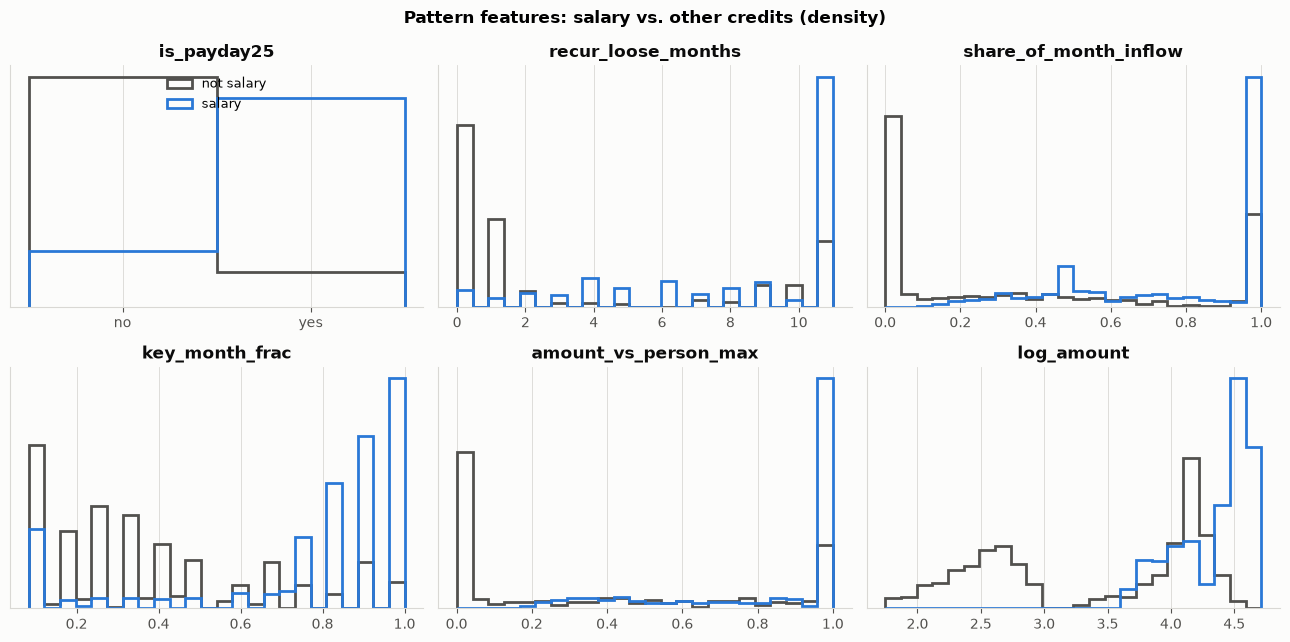

In [7]:
show = ["is_payday25", "recur_loose_months", "share_of_month_inflow",
        "key_month_frac", "amount_vs_person_max", "log_amount"]
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5))
for ax, col in zip(axes.flat, show):
    lo, hi = X[col].min(), X[col].max()
    bins = np.linspace(lo, hi, 25) if X[col].nunique() > 2 else [-0.5, 0.5, 1.5]
    for is_sal, color, label in [(False, COLORS["muted"], "not salary"), (True, COLORS["blue"], "salary")]:
        ax.hist(X.loc[X.is_salary == is_sal, col], bins=bins, density=True, histtype="step", lw=2,
                color=color, label=label)
    ax.set(title=col, yticks=[])
    if X[col].nunique() == 2:
        ax.set_xticks([0, 1], ["no", "yes"])
axes[0, 0].legend(frameon=False, loc="upper center")
fig.suptitle("Pattern features: salary vs. other credits (density)", fontweight="bold")
save(fig, FIG / "features_separation.png")

In [8]:
means = X.groupby("is_salary")[FEATURE_COLS].mean().T.rename(columns={False: "not salary", True: "salary"})
means["type"] = ["text" if c in TEXT_COLS else "pattern" for c in means.index]
means.round(2)

is_salary,not salary,salary,type
kw_salary,0.05,0.65,text
kw_bonus_holiday,0.00,0.03,text
kw_payout,0.02,0.05,text
kw_employer,0.00,0.36,text
kw_pension,0.11,0.00,text
kw_student_aid,0.06,0.00,text
kw_unemployment,0.04,0.00,text
kw_social_insurance,0.04,0.00,text
kw_tax_refund,0.02,0.00,text
kw_insurance,0.05,0.00,text


## 4. Final model: logistic regression

The features are standardised, then fed to a logistic regression with threshold 0.5. It is
trained on **all 100 persons**. The honest out-of-sample evaluation is in notebook 03.

- **Why not gradient boosting?** In the same person-grouped CV it scored lower (F1 0.983 vs
  0.996). The trees overfit amount thresholds (notebook 03).
- **Why is logistic regression good here?** It is explainable coefficient by coefficient, and
  100 persons is small data.

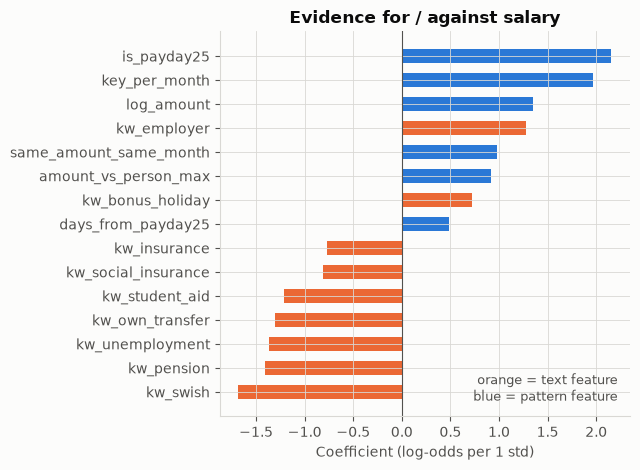

In [9]:
model = fit(make_logreg(), X)
save_model(model)

coef = pd.Series(model[-1].coef_[0], index=FEATURE_COLS, name="coef").sort_values()
coef.round(3).to_csv(REPORTS / "model_coefficients.csv")
top = pd.concat([coef.head(7), coef.tail(8)])

fig, ax = plt.subplots(figsize=(6.5, 4.8))
ax.barh(top.index, top.values, height=0.6,
        color=[COLORS["orange"] if c in TEXT_COLS else COLORS["blue"] for c in top.index])
ax.axvline(0, color=COLORS["muted"], lw=0.8)
ax.set(xlabel="Coefficient (log-odds per 1 std)", title="Evidence for / against salary")
ax.text(0.97, 0.03, "orange = text feature\nblue = pattern feature", transform=ax.transAxes,
        ha="right", va="bottom", color=COLORS["muted"], fontsize=9)
save(fig, FIG / "coefficients.png")

**Reading the coefficients:**
- *For* salary: on the 25th payday, one payment per month from the same payer, a large amount,
  an employer name, and split pay.
- *Against* salary: Swish, pension, a-kassa, CSN, own transfers, insurance.
- Several recurrence features measure the same thing in different ways, so they share weight.
  Read them as a group, not one by one.

## 5. Predictions

We save two scores per transaction:
- `proba`: the final model trained on everyone. This is what production would output.
- `proba_oof`: the score from a model that never saw that person (person-grouped 5-fold CV).
  Only this one is honest for evaluation.

In [10]:
X["proba"] = predict_proba(model, X)
X["proba_oof"] = oof_predict(make_logreg, X, FEATURE_COLS, seed=0)

OUT = ROOT / "outputs"
OUT.mkdir(exist_ok=True)
preds = txns.merge(X[["txn_id", "proba", "proba_oof"]], on="txn_id", how="left")
preds[["proba", "proba_oof"]] = preds[["proba", "proba_oof"]].fillna(0.0)   # debits are never salary
preds["pred_is_salary"] = preds.proba >= THRESHOLD
preds.drop(columns=["n_accounts"]).to_csv(OUT / "predictions.csv", index=False)

per = person_income(X, X.proba_oof.to_numpy() >= THRESHOLD, txns)
per.round(2).to_csv(OUT / "person_income.csv")

print(f"in-sample: {int(preds.pred_is_salary.sum())} predicted vs {int(preds.is_salary.sum())} labelled salaries")
print(f"held-out:  {int((X.proba_oof >= THRESHOLD).sum())} predicted")
per.sort_values("true_monthly", ascending=False).head(8)[
    ["months", "true_monthly", "pred_monthly", "abs_pct_err"]].round({"true_monthly": 0, "pred_monthly": 0, "abs_pct_err": 3})

in-sample: 876 predicted vs 876 labelled salaries
held-out:  878 predicted


,months,true_monthly,pred_monthly,abs_pct_err
person_id,,,,
P036,5,52624.0,52624.0,0.000
P082,12,48286.0,48286.0,0.000
P060,12,47630.0,47630.0,0.000
P050,12,47380.0,47380.0,0.000
P078,12,47257.0,44096.0,0.067
P091,12,46094.0,46094.0,0.000
P017,12,45974.0,45974.0,0.000
P045,12,45131.0,45131.0,0.000


To score a new file in the same JSON format (no labels needed):
`python src/predict.py path/to/transactions.json --out scored.csv`.